# Creational design patterns

    - Singleton design pattern
    - Builder design pattern

In [80]:
def singleton(cls):
    instances = {}
    print(f"instances = {instances}")
    def get_instance(*args, **kwargs):
        if cls not in instances:
            print("creating new object...")
            instances[cls] = cls(*args, **kwargs)  # 
        else:
            print("object already exists...")
        return instances[cls]
    
    return get_instance  # return a function

In [81]:
@singleton
class Logger:
    def __init__(self): 
        print("initializing logger...")
        
@singleton        
class DBconnector:
    pass

@singleton
class monitor:
    pass

instances = {}
instances = {}
instances = {}


# When i executed this then why 3 times empty instances are getting printed.

    
    This is a classic "decorator execution timing" concept
    - This happens because when we define a class with any @decorator it gets executed during DEFENITION time
    - Later when you instantiate the object of the class, then it will get executed again.
    - So, during definition python stores each class (whichever is decorated with singleton) with its own state/closure
    - They will not share state/closure within themselves.
    
    - That's 3 separate calls to singleton(), so instances = {} prints 3 times — once per class, not per object.
    
    
    So:

    Logger's get_instance closure has its own instances dict
    DBconnector's get_instance closure has its own separate instances dict
    monitor's get_instance closure has its own separate instances dict

    They don't share state — which is actually what you want here, since you want one instance per class, not one instance total across all classes.

In [78]:
l1 = Logger()
print(id(l1))

print("*"*20)

l2 = Logger()
print(id(l2))

creating new object...
initializing logger...
1611965233680
********************
object already exists...
1611965233680


In [79]:
d1 = DBconnector()
d2 = DBconnector()
print(id(d1), id(d2))

creating new object...
object already exists...
1611963556464 1611963556464


# Singleton can be acheived via @lru_cache (Least Recently Used)

In [53]:
from functools import lru_cache

@lru_cache(maxsize=1) # @singleton
class Logger:
    def __init__(self): 
        print("initializing logger...")

In [54]:
l1 = Logger()
print(id(l1))

print("*"*20)

l2 = Logger()
print(id(l2))

initializing logger...
1611963556464
********************
1611963556464


# Alternative magic method  __ new __()

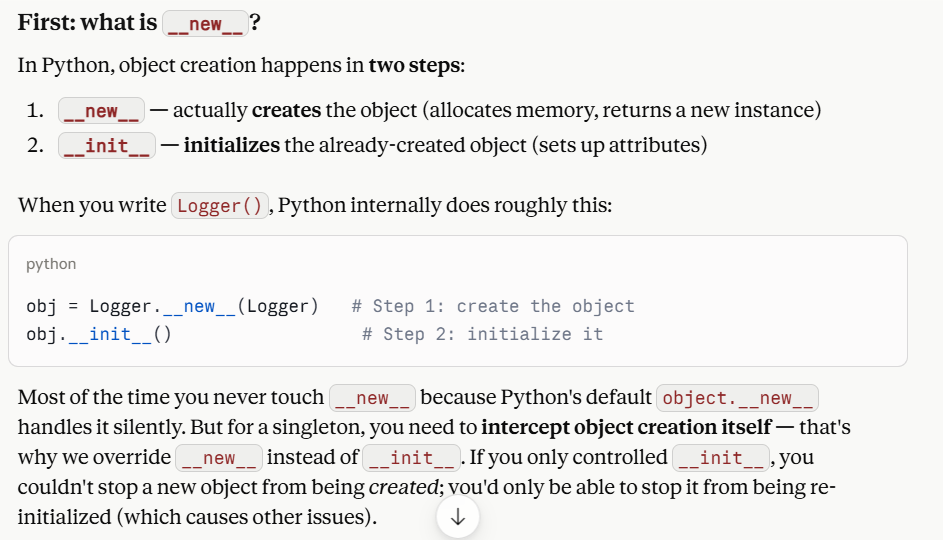

In [90]:
class Logger:
    
    _instance = None # class variable which will keep a track of instance is existing or not
    
    def __init__(self):
        self.log_file = "mylog.txt"
        print("init is called..")
    
    def __new__(cls, *args, **kwargs):
        
        print("new magic method is called...")
        if cls._instance is None:
            cls._instance = super().__new__(cls)
            cls._instance.log_file = "mylog.txt"
        return cls._instance
        
    def log(self, msg):
        print(f"Logging msg => {msg}")

In [91]:
logger_obj = Logger()
logger_obj1 = Logger()


new magic method is called...
init is called..
new magic method is called...
init is called..


In [92]:
id(logger_obj), id(logger_obj1)

(1611973543648, 1611973543648)

In [75]:
dir(Logger)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'log']

In [133]:
from dataclasses import dataclass, field

In [139]:
class Pizza:
    def __init__(self, toppings=[]):
        self.toppings = toppings

In [140]:
p1 = Pizza()
p1.toppings.append("mushroom")
p2 = Pizza()

print(p1.toppings)
print(p2.toppings)  # p2 should not have mushroom, we only added in p1!! so we need to use dataclasses & fields

['mushroom']
['mushroom']


In [141]:
class BadExample:
    def __init__(self, toppings=[]):  # shared across ALL instances!
        self.toppings = toppings

p1 = BadExample()
p1.toppings.append("cheese")
p2 = BadExample()
print(p2.toppings)  # ['cheese']  <- BUG! p2 shouldn't have this

['cheese']


# Dataclass

In [155]:
from dataclasses import dataclass, field

@dataclass
class Pizza:
    toppings: list = field(default_factory=list)

In [157]:
p1 = Pizza()  # toppings="mushrooms"
print(p1)
p1.toppings.append("chicken")
print(p1)

Pizza(toppings=[])
Pizza(toppings=['chicken'])


In [159]:
p2 = Pizza()
p2  # now if you notice then p2 and p1 do not share the mutable objects bcoz of dataclass

Pizza(toppings=[])